In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import permutation_test

In [36]:
loglik = pd.read_csv('combined.csv')
loglik.head()

,Unnamed: 0,measure,model,fold,loglik
0,0,firstrun.reg.out,baseline,0,-0.523254
1,1,firstrun.reg.out,word_surprisal,0,-0.522243
2,2,firstrun.reg.out,kl_backward,0,-0.523378
3,3,firstrun.reg.out,tagger_kl_backward,0,-0.523451
4,4,firstrun.dur,baseline,0,-6.398520


In [37]:
measures = set(loglik['measure'])
metrics = set(loglik['model'])
metrics.discard('baseline')
# folds = set(loglik['fold'])
folds = range(6)

In [38]:
fold

0

In [39]:
delta_logliks = {
    'fold': [],
    'measure': [],
    'metric': [],
    'dloglik': []
}

for fold in folds:
    for measure in measures:
        baseline_row = loglik[(loglik['fold'] == fold) & (loglik['measure'] == measure) & (loglik['model'] == 'baseline')]
        print(measure, fold)
        baseline_loglik = float(baseline_row['loglik'].iloc[0])
        for metric in metrics:
            metric_row = loglik[(loglik['fold'] == fold) & (loglik['measure'] == measure) & (loglik['model'] == metric)]
            if metric.split('_')[0] not in ['word', 'tagger']:
                metric = f'parser_{metric}'
            metric_loglik = float(metric_row['loglik'].iloc[0])
            dloglik = metric_loglik - baseline_loglik
            delta_logliks['fold'].append(fold)
            delta_logliks['metric'].append(metric)
            delta_logliks['dloglik'].append(dloglik)
            delta_logliks['measure'].append(measure)

delta_logliks = pd.DataFrame(delta_logliks)
delta_logliks.head()

firstrun.gopast.sel 0
firstrun.dur 0
firstrun.reg.out 0
regressive.gopast 0
firstrun.gopast.sel 1
firstrun.dur 1
firstrun.reg.out 1
regressive.gopast 1
firstrun.gopast.sel 2
firstrun.dur 2
firstrun.reg.out 2
regressive.gopast 2
firstrun.gopast.sel 3
firstrun.dur 3
firstrun.reg.out 3
regressive.gopast 3
firstrun.gopast.sel 4
firstrun.dur 4
firstrun.reg.out 4
regressive.gopast 4
firstrun.gopast.sel 5
firstrun.dur 5
firstrun.reg.out 5
regressive.gopast 5


,fold,measure,metric,dloglik
0,0,firstrun.gopast.sel,word_surprisal,0.003460
1,0,firstrun.gopast.sel,parser_renyi_divergence_backward_2,0.023013
2,0,firstrun.gopast.sel,tagger_renyi_divergence_backward_2,0.025132
3,0,firstrun.gopast.sel,tagger_renyi_divergence_backward_4,0.025222
4,0,firstrun.gopast.sel,parser_renyi_divergence_backward_4,0.023294


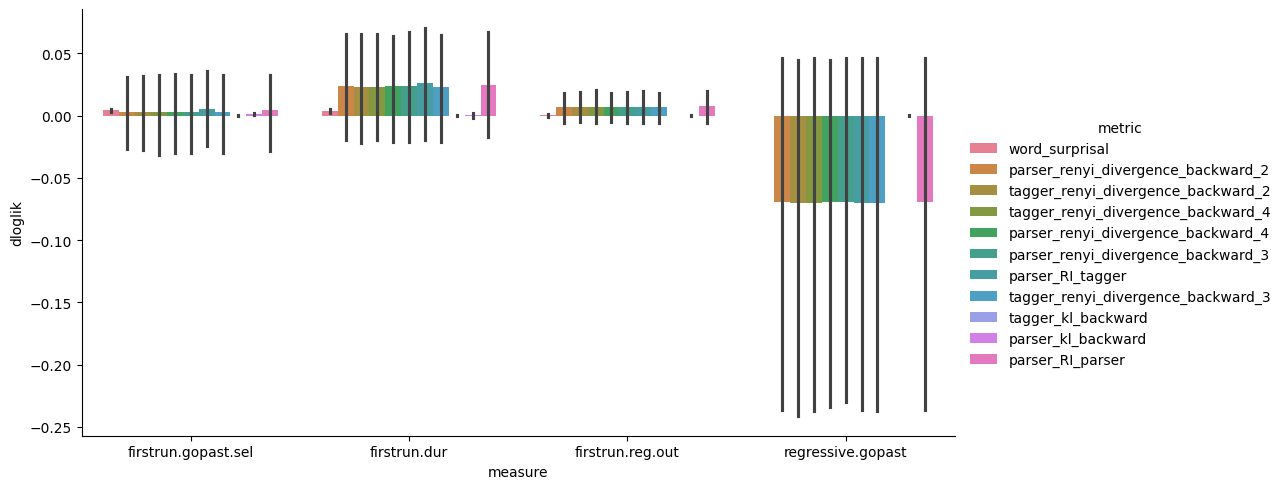

In [40]:
sns.catplot(
    data=delta_logliks,
    x='measure',
    y='dloglik',
    hue='metric',
    kind='bar',
    height=5,
    aspect=2,
)

In [22]:
p_values = {
    'measure': [],
    'metric': [],
    'p': [],
}

def stars(p):
    if p< 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

for measure in measures:
    for metric in metrics:
        if metric.split('_')[0] not in ['word', 'tagger']:
            metric = f'parser_{metric}'
        data = delta_logliks[(delta_logliks['measure'] == measure) & (delta_logliks['metric'] == metric)]
        data = data['dloglik'].to_numpy()
        test = permutation_test(
            [data],
            statistic=lambda x: np.mean(x),
            permutation_type='samples',
            alternative='two-sided',
        )
        p = test.pvalue
        sig_stars = stars(p)
        p_values['measure'].append(measure)
        p_values['metric'].append(f'{metric}{sig_stars}')
        p_values['p'].append(p)

p_values = pd.DataFrame(p_values)

In [23]:
p_values

,measure,metric,p
0,firstrun.gopast.sel,parser_renyi_divergence_backward_2,0.50000
1,firstrun.gopast.sel,tagger_renyi_divergence_backward_2,0.59375
2,firstrun.gopast.sel,tagger_renyi_divergence_backward_4,0.78125
3,firstrun.gopast.sel,parser_renyi_divergence_backward_4,0.62500
4,firstrun.gopast.sel,parser_renyi_divergence_backward_3,0.56250
5,firstrun.gopast.sel,parser_RI_tagger*,0.03125
6,firstrun.gopast.sel,tagger_renyi_divergence_backward_3,0.75000
7,firstrun.gopast.sel,parser_RI_parser,0.09375
8,firstrun.dur,parser_renyi_divergence_backward_2,0.78125
9,firstrun.dur,tagger_renyi_divergence_backward_2,0.21875
